In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

current_path = Path.cwd()

if current_path.name == "notebooks":
    project_root = current_path.parent
else:
    project_root = current_path

data_path = project_root / "data" / "processed" / "student_dropout_cleaned.csv"
figures_path = project_root / "reports" / "figures"
figures_path.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (3630, 37)


,marital_status,application_mode,application_order,course,daytime_evening_attendance,previous_qualification,previous_qualification_grade,nacionality,mothers_qualification,fathers_qualification,...,curricular_units_2nd_sem_credited,curricular_units_2nd_sem_enrolled,curricular_units_2nd_sem_evaluations,curricular_units_2nd_sem_approved,curricular_units_2nd_sem_grade,curricular_units_2nd_sem_without_evaluations,unemployment_rate,inflation_rate,gdp,dropout_risk
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,1
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,0
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,1
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,0
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,0


TARGET DISTRIBUTION: SHOW HOW MANY GRADUATES AND DROPOUTS

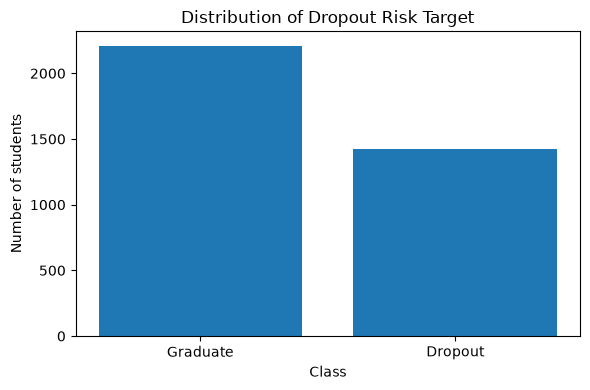

dropout_risk
0    2209
1    1421
Name: count, dtype: int64

In [2]:
target_counts = df["dropout_risk"].value_counts().sort_index()
target_labels = ["Graduate", "Dropout"]

plt.figure(figsize=(6, 4))
plt.bar(target_labels, target_counts.values)
plt.title("Distribution of Dropout Risk Target")
plt.xlabel("Class")
plt.ylabel("Number of students")
plt.tight_layout()

plt.savefig(figures_path / "target_distribution.png", dpi=300)
plt.show()

target_counts

TARGET PERCENTAGE PIE CHART: FOR SHOWING CLASS BALANCE

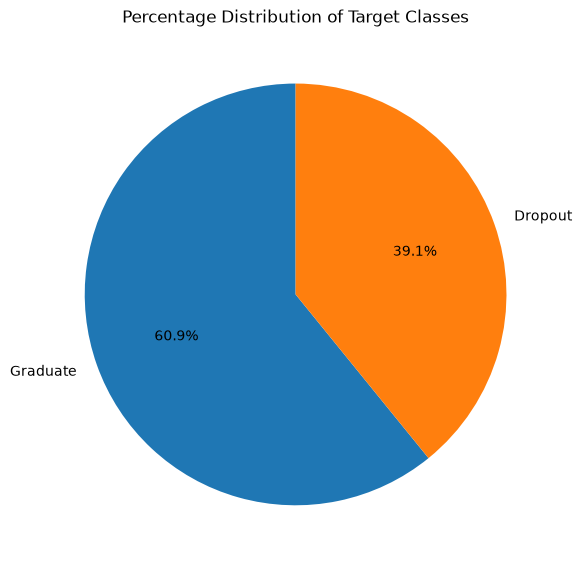

dropout_risk
0    60.853994
1    39.146006
Name: proportion, dtype: float64

In [3]:
target_percentages = df["dropout_risk"].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(6, 6))
plt.pie(
    target_percentages.values,
    labels=["Graduate", "Dropout"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Percentage Distribution of Target Classes")
plt.tight_layout()

plt.savefig(figures_path / "target_percentage_pie.png", dpi=300)
plt.show()

target_percentages

AGE DISTRIBUTION BY OUTCOME: SHOW WHETHER DROPOUT AND GRADUATE STUDENTS DIFFER BY AGE

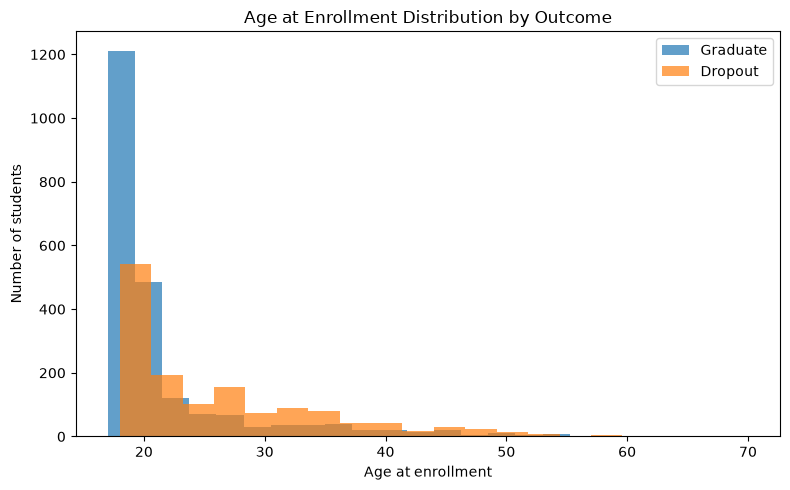

In [5]:
graduate_age = df[df["dropout_risk"] == 0]["age_at_enrollment"]
dropout_age = df[df["dropout_risk"] == 1]["age_at_enrollment"]

plt.figure(figsize=(8, 5))
plt.hist(graduate_age, bins=20, alpha=0.7, label="Graduate")
plt.hist(dropout_age, bins=20, alpha=0.7, label="Dropout")
plt.title("Age at Enrollment Distribution by Outcome")
plt.xlabel("Age at enrollment")
plt.ylabel("Number of students")
plt.legend()
plt.tight_layout()

plt.savefig(figures_path / "age_distribution_by_outcome.png", dpi=300)
plt.show()

First-semester approved units by outcome: very important because SHAP showed it as the top feature

<Figure size 700x500 with 0 Axes>

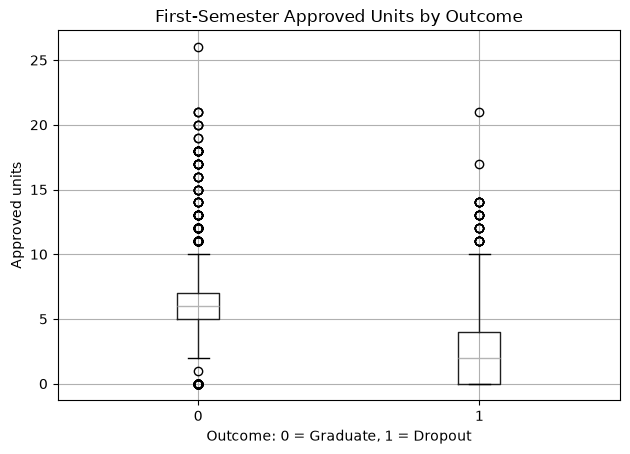

In [6]:
plt.figure(figsize=(7, 5))
df.boxplot(
    column="curricular_units_1st_sem_approved",
    by="dropout_risk"
)
plt.title("First-Semester Approved Units by Outcome")
plt.suptitle("")
plt.xlabel("Outcome: 0 = Graduate, 1 = Dropout")
plt.ylabel("Approved units")
plt.tight_layout()

plt.savefig(figures_path / "approved_units_by_outcome.png", dpi=300)
plt.show()

First-semester grade by outcome

<Figure size 700x500 with 0 Axes>

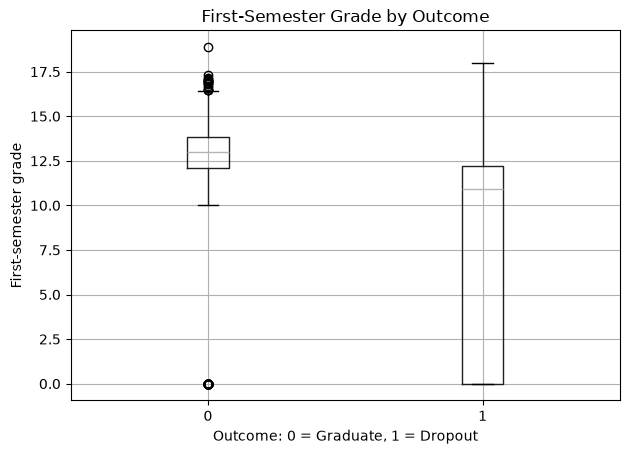

In [7]:
plt.figure(figsize=(7, 5))
df.boxplot(
    column="curricular_units_1st_sem_grade",
    by="dropout_risk"
)
plt.title("First-Semester Grade by Outcome")
plt.suptitle("")
plt.xlabel("Outcome: 0 = Graduate, 1 = Dropout")
plt.ylabel("First-semester grade")
plt.tight_layout()

plt.savefig(figures_path / "first_semester_grade_by_outcome.png", dpi=300)
plt.show()

Tuition fees up to date vs dropout risk

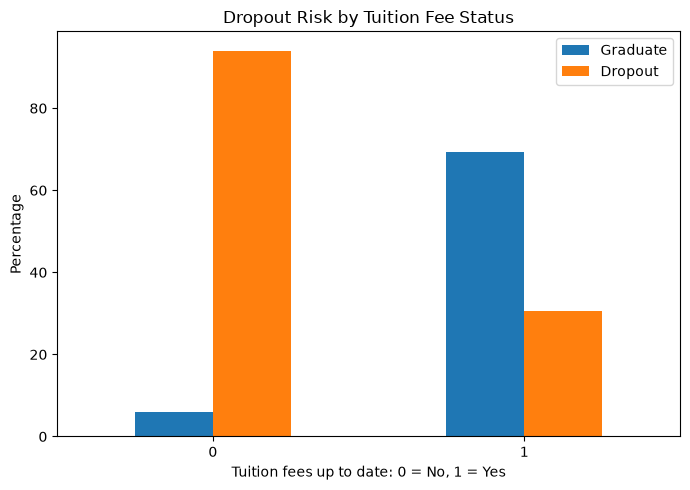

,Graduate,Dropout
tuition_fees_up_to_date,,
0,5.967078,94.032922
1,69.338422,30.661578


In [8]:
tuition_table = pd.crosstab(
    df["tuition_fees_up_to_date"],
    df["dropout_risk"],
    normalize="index"
) * 100

tuition_table.columns = ["Graduate", "Dropout"]

tuition_table.plot(kind="bar", figsize=(7, 5))
plt.title("Dropout Risk by Tuition Fee Status")
plt.xlabel("Tuition fees up to date: 0 = No, 1 = Yes")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(figures_path / "dropout_by_tuition_status.png", dpi=300)
plt.show()

tuition_table

Debtor status vs dropout risk

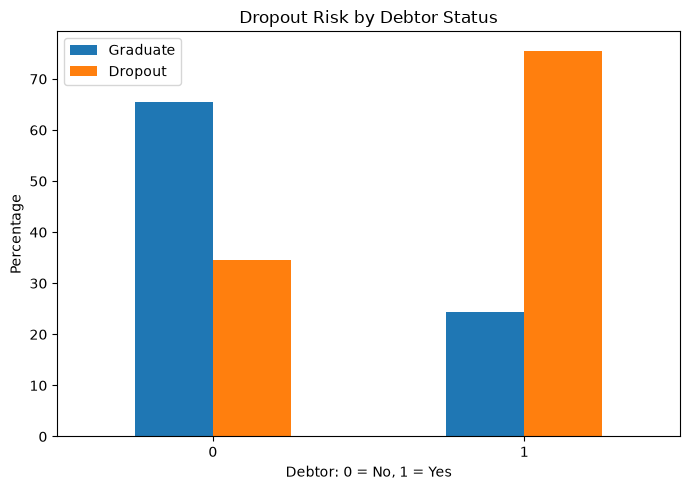

,Graduate,Dropout
debtor,,
0,65.526888,34.473112
1,24.455206,75.544794


In [9]:
debtor_table = pd.crosstab(
    df["debtor"],
    df["dropout_risk"],
    normalize="index"
) * 100

debtor_table.columns = ["Graduate", "Dropout"]

debtor_table.plot(kind="bar", figsize=(7, 5))
plt.title("Dropout Risk by Debtor Status")
plt.xlabel("Debtor: 0 = No, 1 = Yes")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(figures_path / "dropout_by_debtor_status.png", dpi=300)
plt.show()

debtor_table

Top correlations with dropout risk
shows which numeric features are most correlated with dropout risk

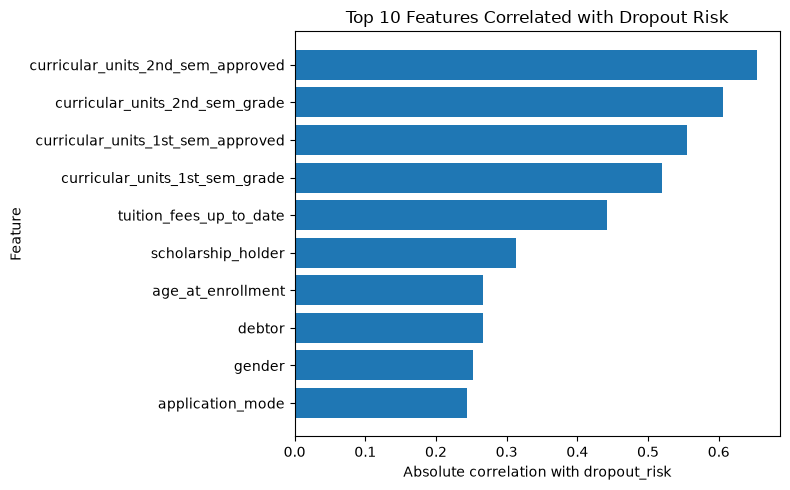

curricular_units_2nd_sem_approved    0.653995
curricular_units_2nd_sem_grade       0.605350
curricular_units_1st_sem_approved    0.554881
curricular_units_1st_sem_grade       0.519927
tuition_fees_up_to_date              0.442138
scholarship_holder                   0.313018
age_at_enrollment                    0.267229
debtor                               0.267207
gender                               0.251955
application_mode                     0.244507
Name: dropout_risk, dtype: float64

In [10]:
correlations = df.corr(numeric_only=True)["dropout_risk"].drop("dropout_risk")
top_correlations = correlations.abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_correlations.index[::-1], top_correlations.values[::-1])
plt.title("Top 10 Features Correlated with Dropout Risk")
plt.xlabel("Absolute correlation with dropout_risk")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(figures_path / "top_correlations_dropout_risk.png", dpi=300)
plt.show()

top_correlations